<div style="display: flex; flex-direction: column; align-items: center; text-align: center; font-family: 'Avenir Next LT Pro', sans-serif; padding: 56px 40px; background: linear-gradient(135deg, #0f172a 0%, #1e293b 55%, #0b1220 100%); border-radius: 18px; box-shadow: 0px 14px 30px rgba(0, 0, 0, 0.25); border: 1px solid rgba(148, 163, 184, 0.18); border-bottom: 5px solid #38bdf8;">
    <p style="margin: 0 0 12px 0; color: #7dd3fc; font-size: 18px; font-weight: 700; letter-spacing: 0.12em; text-transform: uppercase;">Python for Tech Leaders</p>
    <h1 style="font-size: 44px; font-weight: 800; color: #f8fafc; margin: 0; line-height: 1.15;">Machine Learning - Preço das Casas</h1>
    <p style="font-size: 18px; color: #cbd5e1; max-width: 800px; line-height: 1.6; margin: 20px 0 0 0;">
        Será que é possivel prever o preço das casas?
    </p>
</div>

## imports

In [1]:
import scipy as sp
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.tree import plot_tree as sklearn_plot_tree
from xgboost import XGBRegressor
from xgboost import plot_tree as xgb_plot_tree
from sklearn.compose import TransformedTargetRegressor
from pathlib import Path
# Ir buscar a localização deste ficheiro
dir = Path.cwd().parent
data_dir = dir / "data"
print(data_dir)

# Importar funções de visualização personalizadas
sys.path.append(str(dir / "src"))
from plot import plot_hist, plot_corr_heatmap, plot_relevancia_reg

c:\Users\diogo\Desktop\AnalisePreditiva_IA\data


In [ ]:
import os
import sys

# 1. Verifica se o script está a correr no Google Colab
if 'google.colab' in sys.modules:
    print("Ambiente Google Colab detetado. A iniciar a configuração do projeto...")
    
    # Criar a pasta 'data' e descarregar os ficheiros (convertendo o link para o formato SVN)
    if not os.path.exists('data'):
        print("A criar a pasta 'data' e a descarregar os ficheiros...")
        !svn checkout https://github.com/Vullkano/python-for-tech-leaders/trunk/5.%20AI/data data
        # Remove a pasta de metadados do svn para limpar o diretório
        !rm -rf data/.svn
    else:
        print("A pasta 'data' já existe.")

    # Criar a pasta 'src' e descarregar os ficheiros
    if not os.path.exists('src'):
        print("A criar a pasta 'src' e a descarregar os ficheiros...")
        !svn checkout https://github.com/Vullkano/python-for-tech-leaders/trunk/5.%20AI/src src
        # Remove a pasta de metadados do svn para limpar o diretório
        !rm -rf src/.svn
    else:
        print("A pasta 'src' já existe.")
        
    print("\nConfiguração concluída com sucesso!")
else:
    print("Não estás no Google Colab. Nenhuma ação foi tomada.")

# 1. Business Understanding - [Previsão de Preços de Imóveis](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

O setor imobiliário é um dos mercados mais dinâmicos e influenciados por uma vasta combinação de fatores, que vão desde a infraestrutura física até à localização geográfica. Para empresas do setor, investidores ou compradores individuais, a capacidade de estimar com precisão o valor de um imóvel é fundamental para garantir decisões financeiras seguras e competitivas.

**Objetivo do Projeto:**
O objetivo principal deste projeto é desenvolver um modelo de regressão capaz de prever o preço de venda de habitações com base nas suas características (como área, número de quartos, casas de banho, presença de ar condicionado, entre outras). 

Ao contrário dos modelos de classificação que utilizámos anteriormente (onde prevíamos se alguém sobrevivia ou não), aqui o objetivo é prever um **valor numérico contínuo**.

**Problemas a Resolver:**
* Identificar quais as variáveis que têm maior impacto no preço final de um imóvel.
* Criar um modelo robusto que minimize o erro entre o preço previsto e o preço real de mercado.
* Fornecer uma ferramenta de apoio à decisão que permita avaliar se um imóvel está sobrevalorizado ou abaixo do preço de mercado.

# 2. Data Understanding

In [2]:
#Import the data
df_house = pd.read_csv(data_dir / "Housing.csv")
df_house_untouched = df_house.copy()

In [3]:
df_house.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

**Dicionário de Variáveis (Housing Prices Dataset)**

| Variável | Descrição | Tipo de Dado |
| :--- | :--- | :--- |
| **price** | Preço de venda do imóvel (Variável Alvo/Target). | Numérico |
| **area** | Área total do terreno em pés quadrados. | Numérico |
| **bedrooms** | Número de quartos na habitação. | Numérico |
| **bathrooms** | Número de casas de banho. | Numérico |
| **stories** | Número de andares da casa. | Numérico |
| **mainroad** | Indica se a casa está ligada à estrada principal (Yes/No). | Categórico |
| **guestroom** | Indica se a casa possui um quarto de hóspedes (Yes/No). | Categórico |
| **basement** | Indica se a casa possui cave (Yes/No). | Categórico |
| **hotwaterheating** | Indica se a casa tem sistema de aquecimento de água (Yes/No). | Categórico |
| **airconditioning** | Indica se a casa possui ar condicionado (Yes/No). | Categórico |
| **parking** | Número de lugares de estacionamento/garagem. | Numérico |
| **prefarea** | Indica se a casa está numa área preferencial da cidade (Yes/No). | Categórico |
| **furnishingstatus** | Estado de mobília (Furnished, Semi-Furnished, Unfurnished). | Categórico |

In [4]:
df_house.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
# Calculamos a soma de nulos
nulos = df_house.isnull().sum()

# Filtramos apenas os maiores que 0, ordenamos e transformamos em Tabela (DataFrame)
nulos[nulos > 0].sort_values(ascending=False).to_frame(name='Qtd Nulos')

,Qtd Nulos


# 3. Data Preparation (simplificado)

In [7]:
# Looking for abnormal outliers
df_house.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Price mean:  4766729.247706422
Price median:  4340000.0


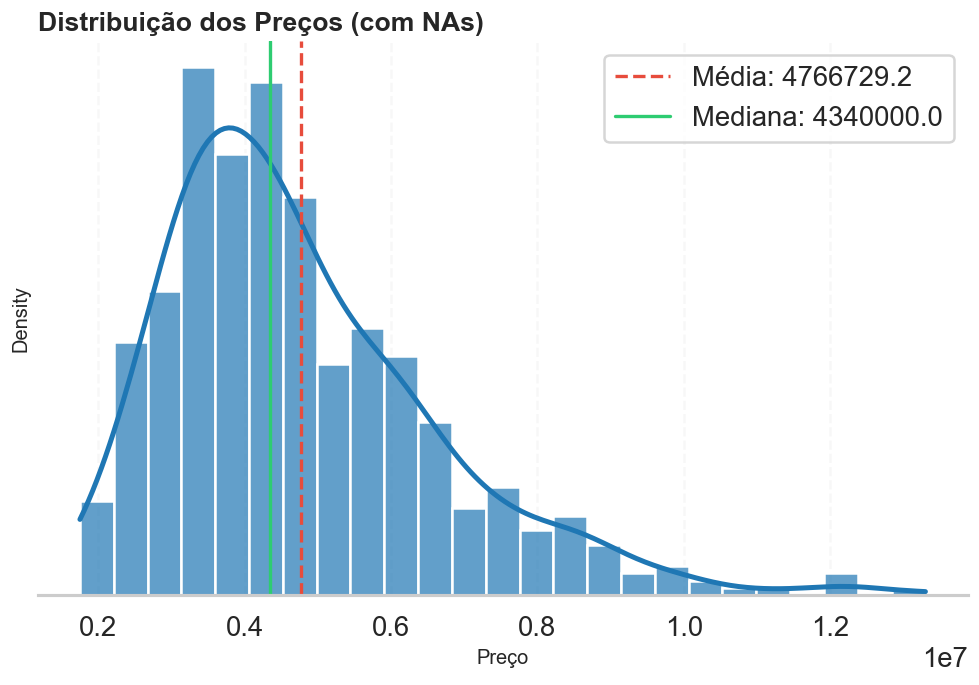

In [8]:
plot_hist(
    df_house['price'].dropna(),
    bins=25,
    kde=True,
    color="#1f77b4",
    title="Distribuição dos Preços (com NAs)",
    xlabel="Preço"
)
print ("Price mean: ", df_house['price'].mean())
print ("Price median: ", df_house['price'].median())
plt.show()

## 3.1. Feature Engineering

In [9]:
# Lista das colunas que são apenas Yes/No
df_house[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished


In [10]:
# 1. Transformação de variáveis binárias (Yes/No para 1/0)
# Criamos uma lista com as colunas identificadas
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Aplicamos o mapeamento em todas as colunas da lista de uma só vez
for col in binary_columns:
    df_house[col] = df_house[col].map({'yes': 1, 'no': 0})

# 2. Transformação da variável categórica (furnishingstatus)
# Como tem 3 categorias, usamos One-Hot Encoding para criar colunas separadas
# O drop_first=True evita a redundância estatística (Dummy Variable Trap)
# Transforma a coluna em colunas 0 e 1 (em vez de False/True)
if 'furnishingstatus' in df_house.columns:
    df_house = pd.get_dummies(df_house, columns=['furnishingstatus'], drop_first=True, dtype=int)
df_house.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## 3.2. Matriz de Correlação

Uma matriz de correlação é uma tabela que exibe os coeficientes de correlação entre vários pares de variáveis, mostrando a força e a direção de suas relações. Os coeficientes de correlação são medidas numéricas que quantificam a força e a direção dessa relação. Aqui usamos o coeficiente de Pearson. 

Valores próximos de 1 ou -1 indicam **correlação forte**, enquanto valores próximos de **0** indicam quase nenhuma correlação.

Em data science, usamos este recurso para selecionar ou excluir variáveis nos modelos com base nas suas relações. Variáveis altamente correlacionadas podem causar multicolinearidade em modelos de regressão, o que pode distorcer os resultados. Ao identificar estas correlações, reduzimos a redundância e melhoramos o desempenho do modelo. **!!**

In [11]:
df_house

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


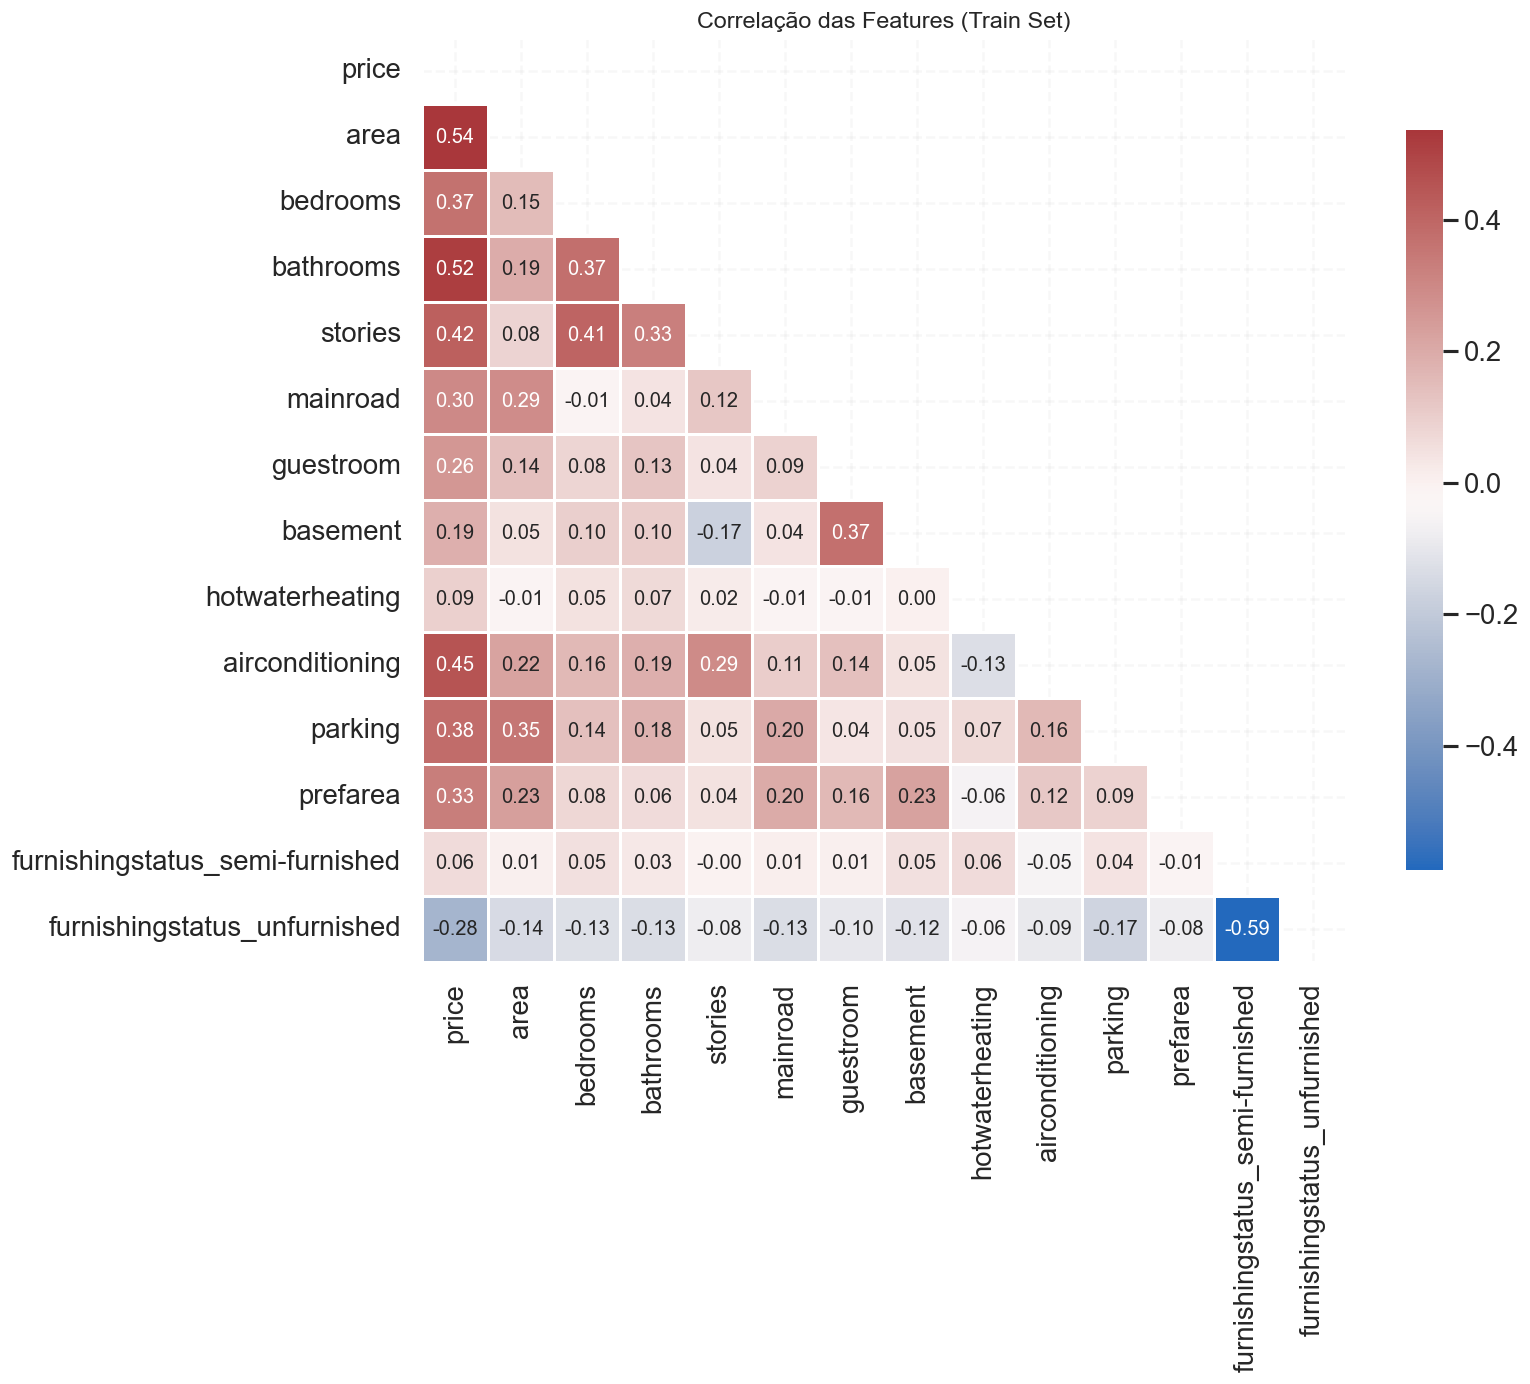

In [12]:
plot_corr_heatmap(
    df_house,
    title="Correlação das Features (Train Set)",
    figsize=(13, 10),
    cmap="vlag",
    annot=True
)
plt.show()

# 4. Modeling

In [13]:
# 1. Separação de Features (X) e Target (y)
X = df_house.drop('price', axis=1)
y = df_house['price']

# 2. Divisão em Treino e Teste (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Escalonamento (Obrigatório para o SVR e melhora a Regressão Linear)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Inicialização dos modelos envolvidos num "Wrapper" que trata do Log e do Exp
models = {
    "Linear Regression": TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p, 
        check_inverse=False,
        inverse_func=np.expm1
    ),
    "Random Forest": TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=100, random_state=42),
        func=np.log1p, 
        inverse_func=np.expm1
    ),
    "Gradient Boosting": TransformedTargetRegressor(
        regressor=GradientBoostingRegressor(random_state=42),
        func=np.log1p, 
        inverse_func=np.expm1
    ),
    "XGBoost": TransformedTargetRegressor(
        regressor=XGBRegressor(
            n_estimators=100,     # Aumentamos as árvores...
            learning_rate=0.05,    # ...mas baixamos o passo para ser mais preciso
            max_depth=6,           # Profundidade ideal para não decorar demais
            subsample=0.8,         # Treina cada árvore com 80% dos dados (evita overfitting)
            colsample_bytree=0.8,  # Treina cada árvore com 80% das colunas
            n_jobs=-1,             # Usa todos os núcleos do teu processador
            random_state=42
        ),
        func=np.log1p, 
        inverse_func=np.expm1
    )
}

reg_results = {}

for name, model in models.items():
    # Agora treinas DIRETAMENTE com o y_train original! 
    # O Wrapper faz o log internamente.
    model.fit(X_train_scaled, y_train)
    
    # A previsão já sai em EUROS automaticamente!
    predictions = model.predict(X_test_scaled)

    # Cálculo das métricas direto
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, predictions)
    
    reg_results[name] = {"MAE": mae, "MSE": mse, "R2": r2, "RMSE": rmse, "MAPE": mape}

In [15]:
def exibir_metricas(nome_modelo):
    if nome_modelo not in reg_results:
        print(f"Modelo '{nome_modelo}' não encontrado. Verifica o nome no dicionário.")
        return

    m = reg_results[nome_modelo]
    
    print(f"\n" + "—"*40)
    print(f"RESUMO DE PERFORMANCE: {nome_modelo.upper()}")
    print(f"—" * 40)
    print(f"R² Score (Poder Explicativo): {m['R2']:.4f}")
    print(f"MAE (Erro Médio Absoluto):    {m['MAE']:,.2f} €")
    print(f"RMSE (Raiz do Erro Quadrático): {m['RMSE']:,.2f} €")
    print(f"MAPE (Erro Percentual Médio): {m['MAPE']:.2%}")
    print(f"MSE (Erro Quadrático Médio):  {m['MSE']:.2e}")
    print(f"—" * 40)

## Linear Regression

![Regressão linear](https://upload.wikimedia.org/wikipedia/commons/4/41/LinearRegression.svg)

A **Regressão Linear** é o modelo base que assume uma relação proporcional e constante entre as características do imóvel e o seu preço final.

* **Funcionamento:** Tenta traçar uma linha reta (ou plano) que minimize a distância entre os preços reais e os previstos. Atribui um peso (coeficiente) a cada variável.
* **Equação:** $Preço = \beta_0 + (\beta_1 \times \text{Área}) + (\beta_2 \times \text{Quartos}) + \dots$
* **Ponto Forte:** É o modelo mais fácil de interpretar. Consegues dizer exatamente quantos euros o preço sobe por cada metro quadrado extra.
* **Limitação:** Não capta relações complexas; assume que tudo no mercado imobiliário funciona de forma "direta", o que nem sempre é verdade.

**Porquê usar:** Serve como o padrão de comparação (*benchmark*). Se modelos complexos não forem muito melhores que este, opta-se pela Regressão Linear pela sua simplicidade.

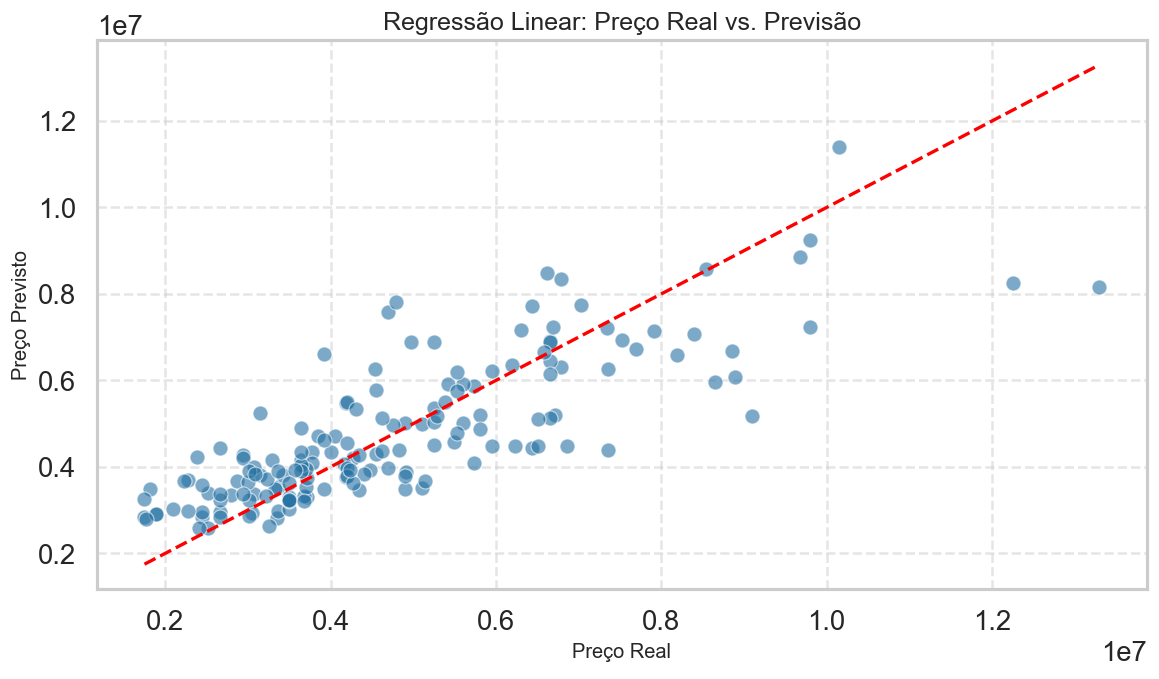

In [16]:
# 1. Obter previsões do modelo de Regressão Linear
lr_model = models["Linear Regression"]
y_pred_lr = lr_model.predict(X_test_scaled)

# 2. Criar o gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='#2471A3')

# Linha de 45 graus (Previsão Perfeita)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', lw=2, linestyle='--')

plt.title('Regressão Linear: Preço Real vs. Previsão', fontsize=15)
plt.xlabel('Preço Real', fontsize=12)
plt.ylabel('Preço Previsto', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
# Exemplos de uso:
exibir_metricas("Linear Regression")


————————————————————————————————————————
RESUMO DE PERFORMANCE: LINEAR REGRESSION
————————————————————————————————————————
R² Score (Poder Explicativo): 0.6554
MAE (Erro Médio Absoluto):    890,026.56 €
RMSE (Raiz do Erro Quadrático): 1,218,103.97 €
MAPE (Erro Percentual Médio): 20.26%
MSE (Erro Quadrático Médio):  1.48e+12
————————————————————————————————————————


In [18]:
from IPython.display import display, Markdown

# Acedemos ao regressor interno dentro do TransformedTargetRegressor
lr_wrapper = models["Linear Regression"]
lr_internal = lr_wrapper.regressor_ 

features = X.columns
coeffs = lr_internal.coef_        
intercept = lr_internal.intercept_ 

# O resto do teu código da fórmula mantém-se igual
formula_latex = rf"$$\mathbf{{Price_{{log}}}} = {intercept:,.2f}"

for f, c in zip(features, coeffs):
    sign = "+" if c >= 0 else "-"
    feature_name = f.replace('_', ' ')
    formula_latex += rf" {sign} ({abs(c):,.2f} \times \text{{{feature_name}}})"

formula_latex += "$$"

display(Markdown("### 📐 Equação Matemática do Modelo (Escala Logarítmica)"))
display(Markdown(formula_latex))

### 📐 Equação Matemática do Modelo (Escala Logarítmica)

$$\mathbf{Price_{log}} = 15.31 + (0.11 \times \text{area}) + (0.02 \times \text{bedrooms}) + (0.09 \times \text{bathrooms}) + (0.07 \times \text{stories}) + (0.04 \times \text{mainroad}) + (0.02 \times \text{guestroom}) + (0.06 \times \text{basement}) + (0.02 \times \text{hotwaterheating}) + (0.06 \times \text{airconditioning}) + (0.04 \times \text{parking}) + (0.04 \times \text{prefarea}) + (0.00 \times \text{furnishingstatus semi-furnished}) - (0.05 \times \text{furnishingstatus unfurnished})$$

c:\Users\diogo\Desktop\AnalisePreditiva_IA\src\plot.py:445: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Relevância', y='Variável', data=df_importancia, palette='viridis')


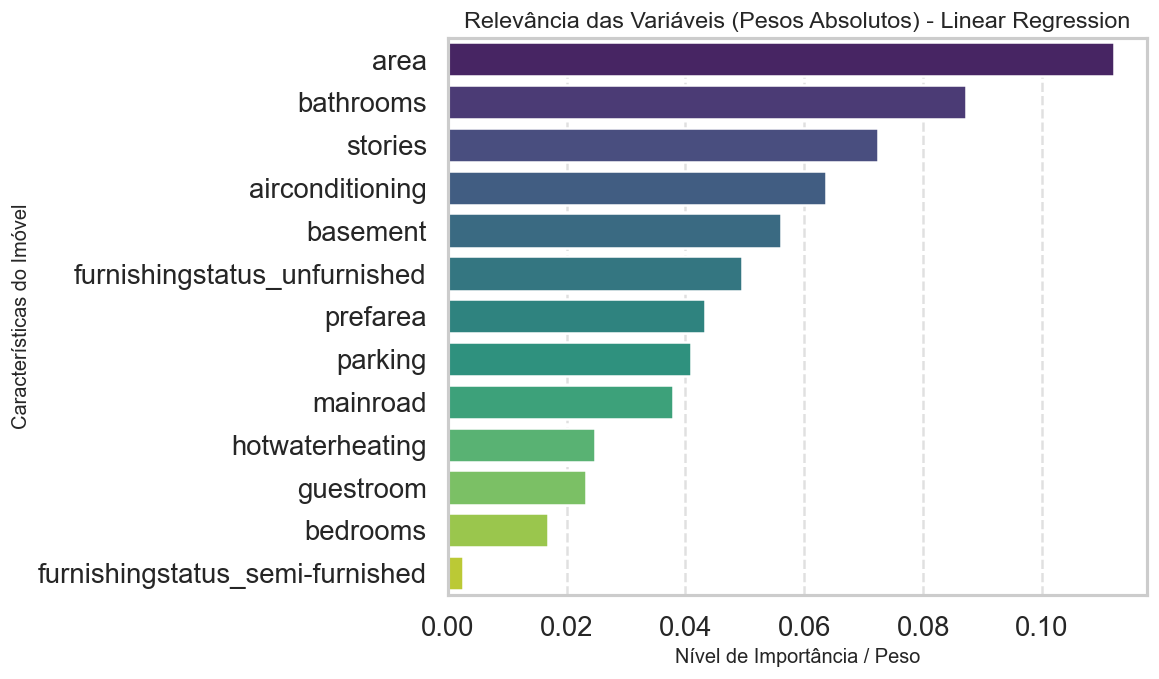

In [19]:
plot_relevancia_reg(models["Linear Regression"].regressor_, X.columns)

## Random Forest

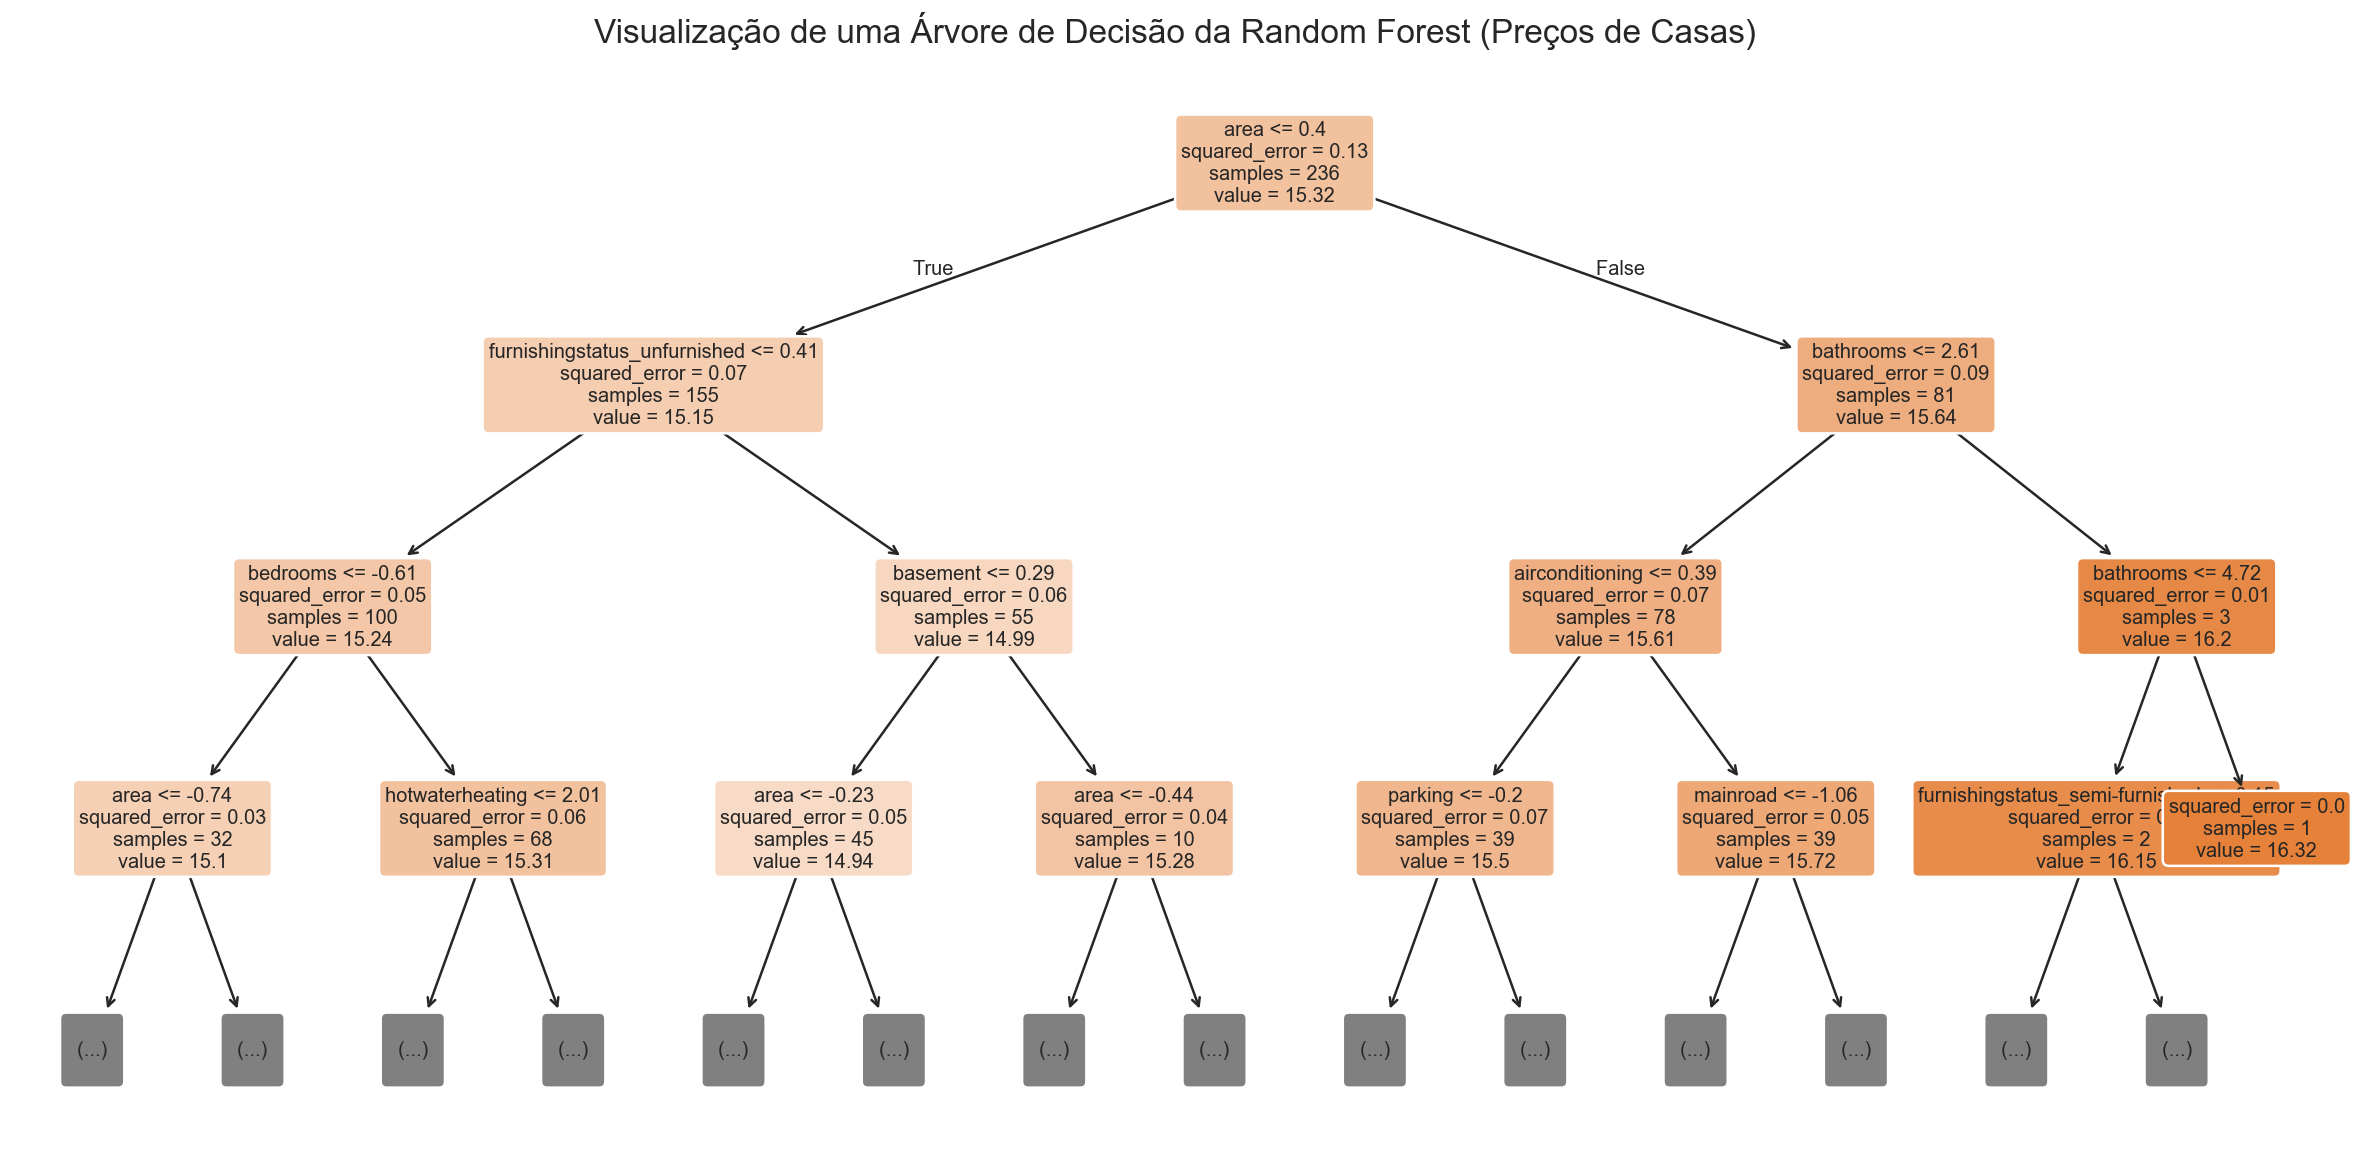

In [20]:
# Selecionamos uma árvore específica da floresta (ex: a primeira, index 0)
plt.figure(figsize=(25, 12))

sklearn_plot_tree(
    models["Random Forest"].regressor_.estimators_[0], 
    feature_names=X.columns, 
    filled=True, 
    rounded=True,
    max_depth=3,      # Limitar a profundidade é vital para a legibilidade
    fontsize=12,
    precision=2       # Número de casas decimais nos valores
)

plt.title("Visualização de uma Árvore de Decisão da Random Forest (Preços de Casas)", fontsize=20)
plt.show()

In [21]:
exibir_metricas("Random Forest")


————————————————————————————————————————
RESUMO DE PERFORMANCE: RANDOM FOREST
————————————————————————————————————————
R² Score (Poder Explicativo): 0.5995
MAE (Erro Médio Absoluto):    918,646.13 €
RMSE (Raiz do Erro Quadrático): 1,313,284.62 €
MAPE (Erro Percentual Médio): 20.80%
MSE (Erro Quadrático Médio):  1.72e+12
————————————————————————————————————————


c:\Users\diogo\Desktop\AnalisePreditiva_IA\src\plot.py:445: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Relevância', y='Variável', data=df_importancia, palette='viridis')


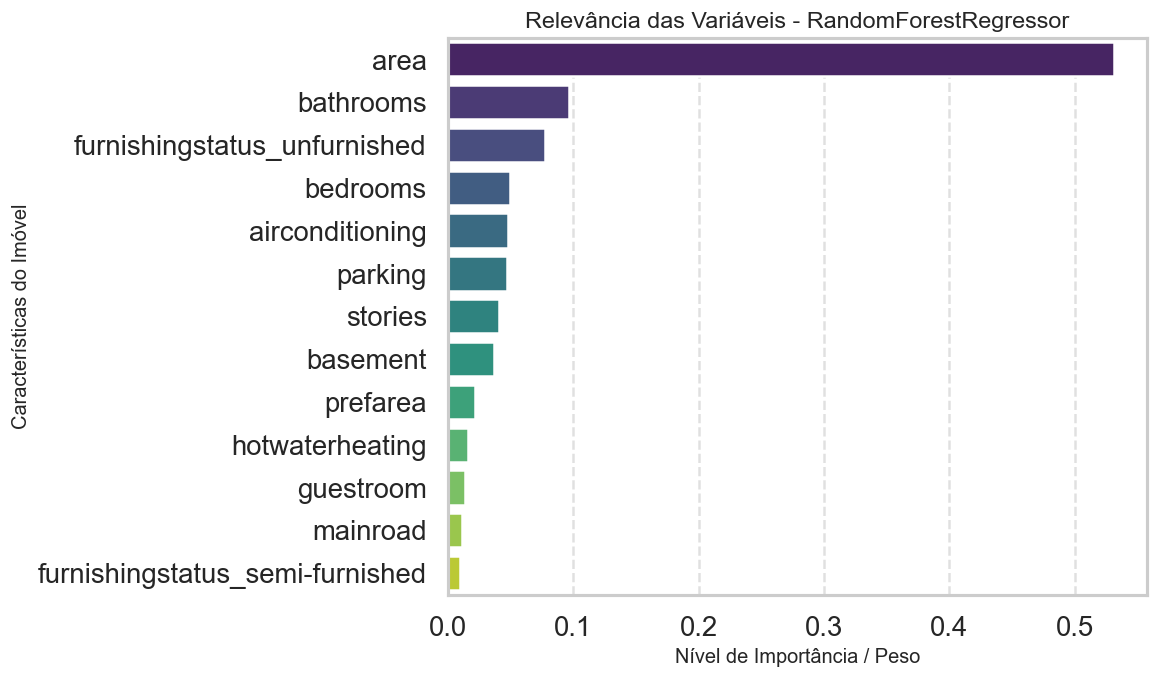

In [22]:
plot_relevancia_reg(models["Random Forest"].regressor_, X.columns)

## Gradient Boosting

![Diagrama de Regressão](https://media.geeksforgeeks.org/wp-content/uploads/20250903173429506712/des.webp)

O **Gradient Boosting** utiliza uma técnica chamada *Boosting*. Em vez de criar uma floresta de árvores completas, ele cria pequenas árvores, uma após a outra.



**Como funciona a lógica:**
1. **Primeira Árvore:** Faz uma previsão simples (muitas vezes apenas a média dos preços).
2. **Cálculo do Erro:** O modelo calcula o "resíduo" (a diferença entre o preço real e a previsão).
3. **Próxima Árvore:** A segunda árvore é treinada para prever **o erro** da primeira, e não o preço final.
4. **Soma:** O modelo soma os resultados. Este processo repete-se centenas de vezes até que o erro seja minimizado.



**O que vemos na árvore:**
* **Learning Rate (Taxa de Aprendizagem):** Cada árvore contribui apenas um pouco para o resultado final. Isto evita que o modelo "decore" ruído nos dados.
* **Nós de Decisão:** Como as árvores são curtas, elas focam-se apenas nas variáveis mais críticas em cada passo (ex: primeiro a `area`, depois talvez `bathrooms` para corrigir os erros da área).

**Vantagem no Mercado Imobiliário:**
É frequentemente o modelo com maior precisão (menor MAE). Ele consegue detetar padrões muito subtis que outros modelos ignoram, tornando-se a escolha ideal quando a precisão do valor do imóvel é a prioridade absoluta.

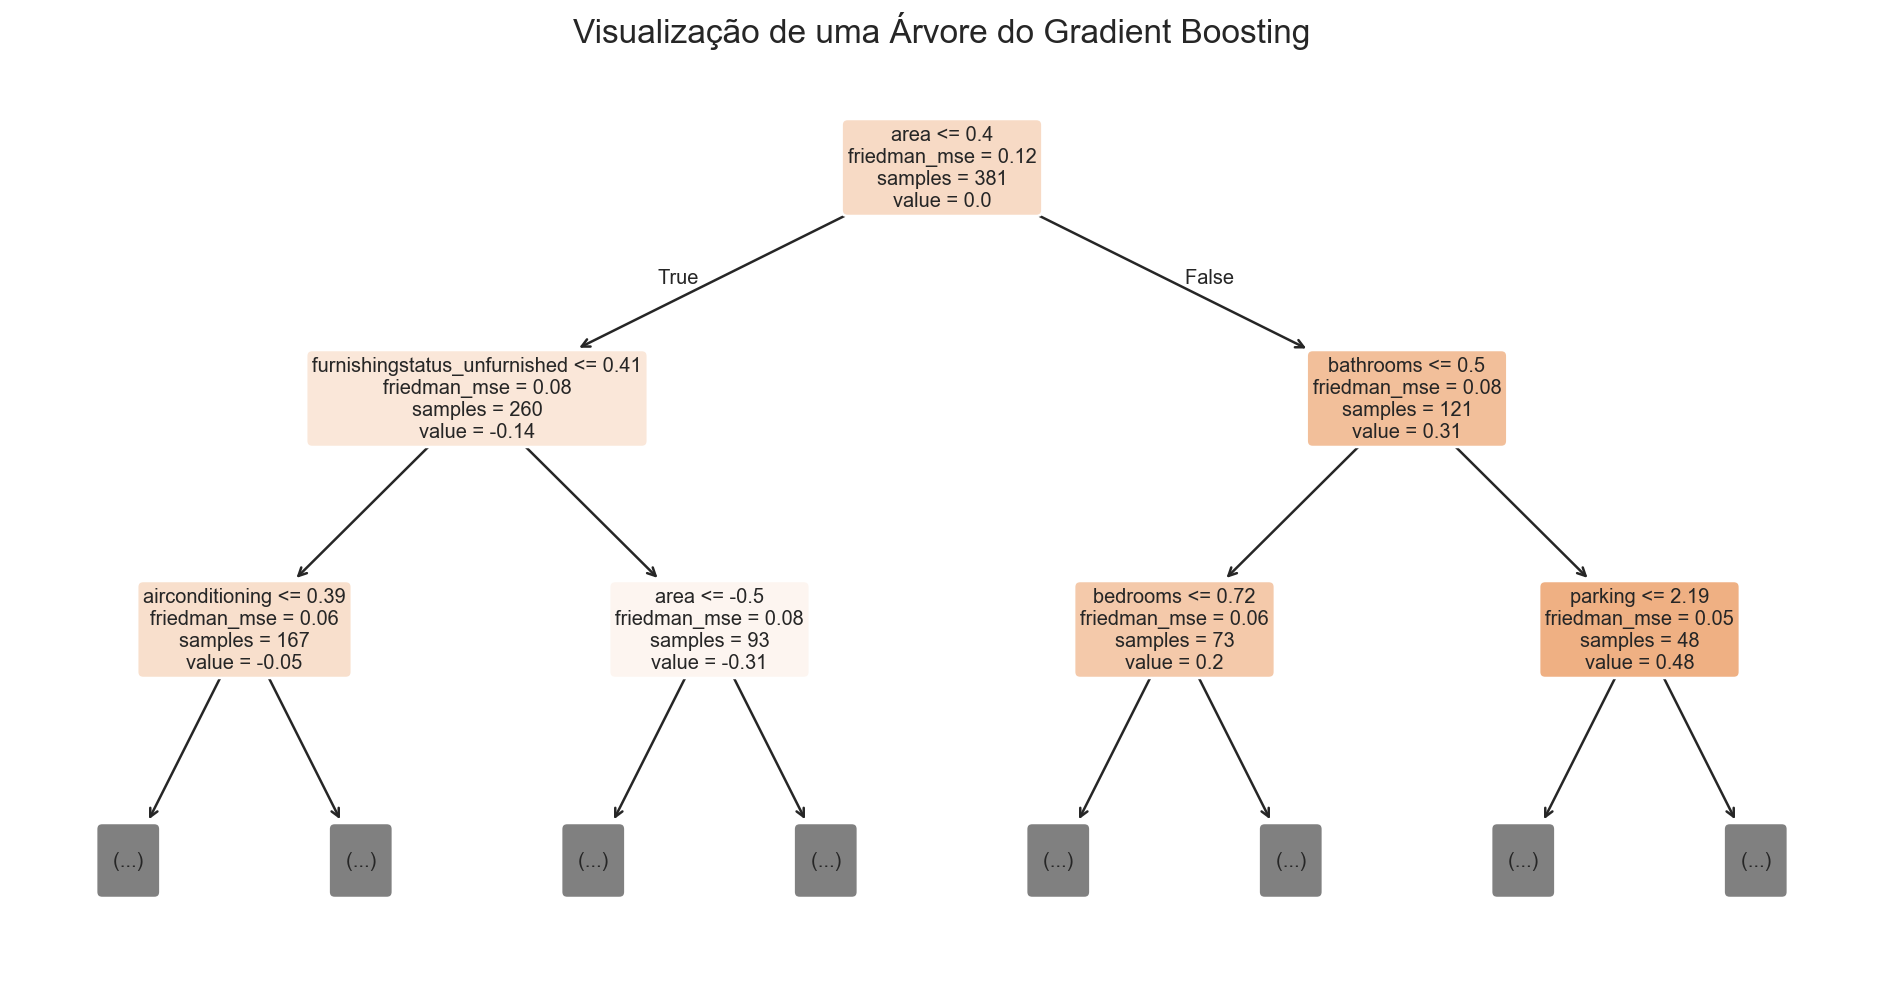

In [23]:
# No Gradient Boosting, as árvores costumam ser muito "rasas" (weak learners)
plt.figure(figsize=(20, 10))

sklearn_plot_tree(
    models["Gradient Boosting"].regressor_.estimators_[0, 0], # Aceder à primeira árvore da sequência
    feature_names=X.columns, 
    filled=True, 
    rounded=True,
    max_depth=2,      # Profundidade baixa para facilitar a leitura
    fontsize=12,
    precision=2
)

plt.title("Visualização de uma Árvore do Gradient Boosting", fontsize=20)
plt.show()

In [24]:
# Exemplos de uso:
exibir_metricas("Gradient Boosting")


————————————————————————————————————————
RESUMO DE PERFORMANCE: GRADIENT BOOSTING
————————————————————————————————————————
R² Score (Poder Explicativo): 0.6561
MAE (Erro Médio Absoluto):    896,188.41 €
RMSE (Raiz do Erro Quadrático): 1,217,026.63 €
MAPE (Erro Percentual Médio): 20.33%
MSE (Erro Quadrático Médio):  1.48e+12
————————————————————————————————————————


c:\Users\diogo\Desktop\AnalisePreditiva_IA\src\plot.py:445: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Relevância', y='Variável', data=df_importancia, palette='viridis')


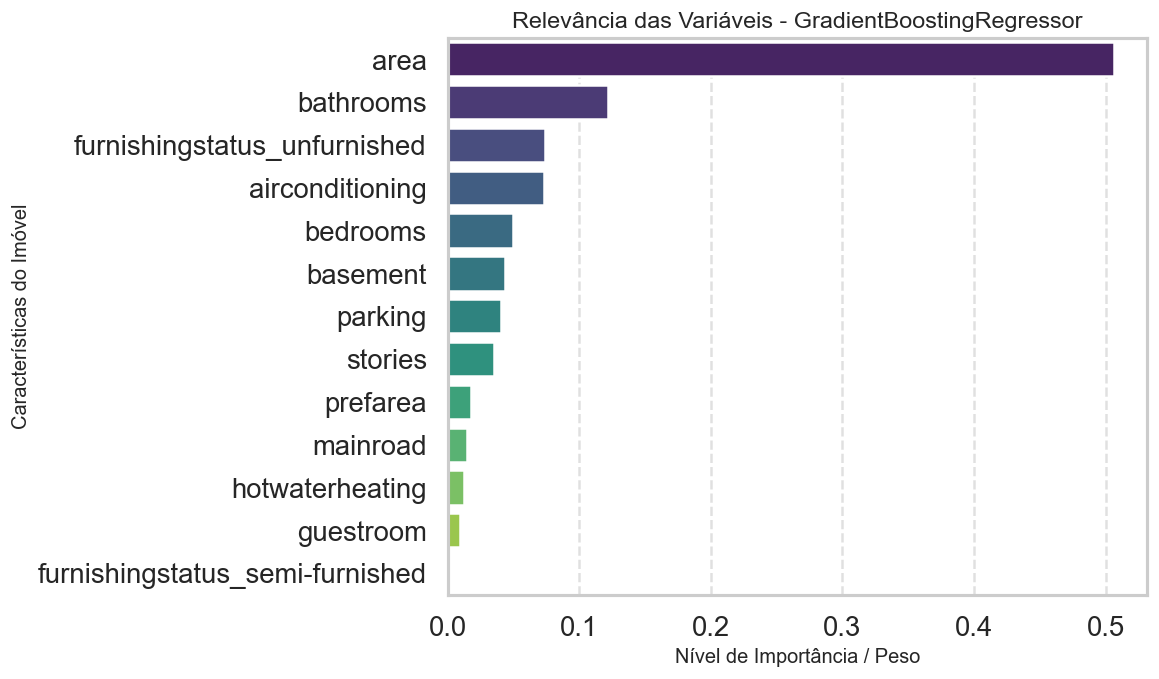

In [25]:
plot_relevancia_reg(models["Gradient Boosting"].regressor_, X.columns)

## XGBRegressor

![XGBoost](https://media.geeksforgeeks.org/wp-content/uploads/20250905153324093033/data_set.webp)

O esquema do **XGBRegressor** ilustra o conceito de **Boosting**, onde o modelo aprende de forma iterativa e cumulativa. Em vez de criar árvores independentes, o algoritmo constrói uma sequência de modelos onde cada um aprende com as falhas do anterior.

No diagrama, os **resíduos** ($e_1, e_2, ...$) representam a diferença entre o preço real e a previsão atual. A primeira árvore ($h_1$) gera uma estimativa inicial; a segunda árvore ($h_2$) é treinada especificamente para prever o erro da primeira. Este processo repete-se sucessivamente até que a soma de todas as previsões ($\hat{y}$) minimize o erro global.

O grande diferencial do XGBoost face ao **Gradient Boosting (GBM)** tradicional é a introdução de **Regularização (L1 e L2)**. Enquanto o GBM foca-se apenas em reduzir o erro, o XGBoost penaliza árvores excessivamente complexas. No contexto do teu projeto, isto evita que o modelo "decore" preços absurdos de mansões específicas, resultando numa generalização muito mais robusta para casas comuns.

Além disso, o XGBoost utiliza um sistema de **Poda (Pruning)** mais inteligente. Ele analisa se o ganho de informação compensa a complexidade da árvore antes de decidir o corte, ao passo que o GBM tradicional é mais "ganancioso" e cresce até atingir os limites impostos, o que o torna mais propenso ao *overfitting*.

Ao utilizares o `TransformedTargetRegressor`, este processo de redução de resíduos acontece na escala logarítmica, o que suaviza a influência de casas com preços extremos e estabiliza a aprendizagem das árvores. Esta combinação de regularização matemática com a transformação do alvo é o que permite ao XGBoost entregar o melhor $R^2$ do teu conjunto de modelos.

C:\Users\diogo\AppData\Local\Temp\ipykernel_35532\2847258197.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


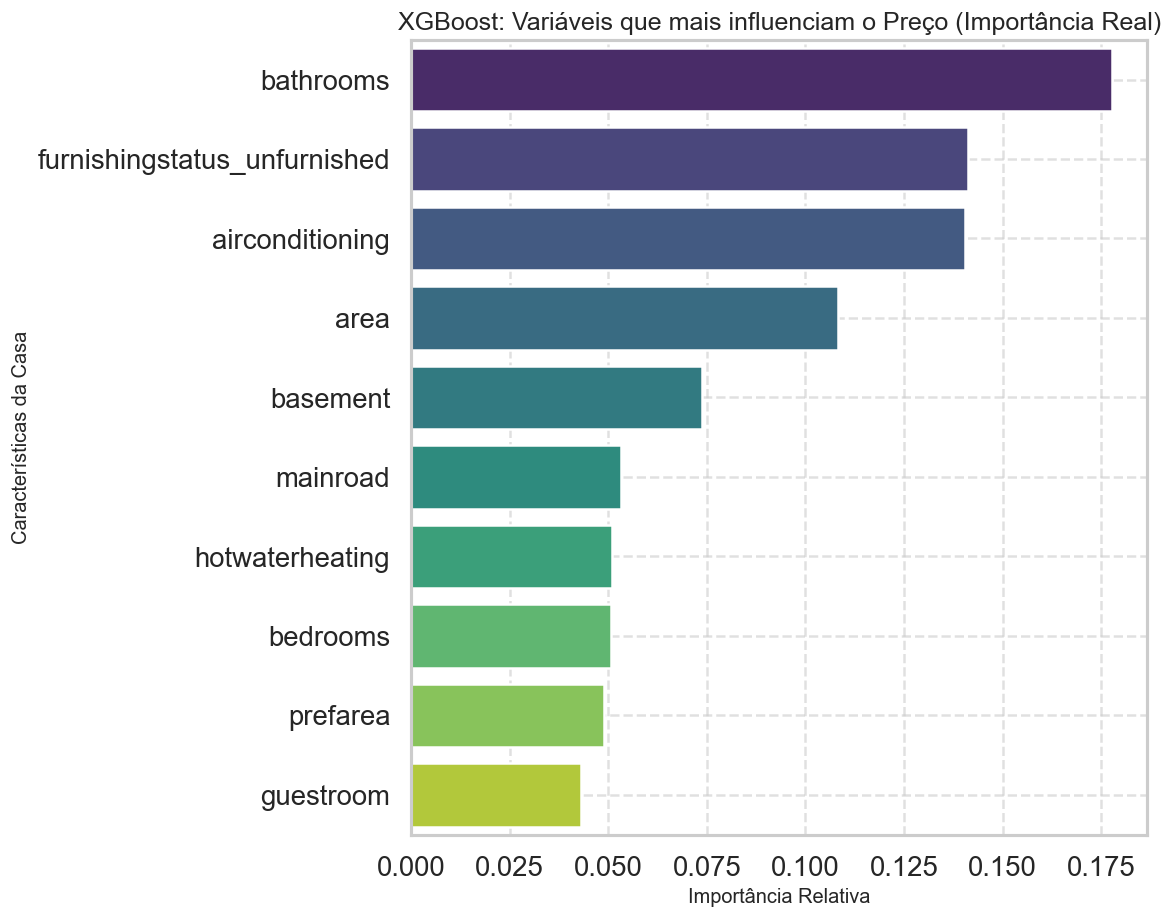

In [26]:
import pandas as pd
import seaborn as sns

# 1. Extrair as importâncias e os nomes das colunas
# O models["XGBoost"].regressor_ contém os ganhos, X.columns contém os nomes reais
importances = models["XGBoost"].regressor_.feature_importances_
feature_names = X.columns

# 2. Criar um DataFrame para facilitar a ordenação e o gráfico
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Criar o gráfico com o Seaborn (muito mais bonito e legível)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')

plt.title('XGBoost: Variáveis que mais influenciam o Preço (Importância Real)', fontsize=15)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Características da Casa', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [27]:
# 1. Recuperar o regressor interno
xgb_internal = models["XGBoost"].regressor_

# 2. Re-injetar os nomes das colunas (IMPORTANTE)
xgb_internal.get_booster().feature_names = list(X.columns)

# 3. Criar o gráfico com DPI alto
fig, ax = plt.subplots(figsize=(40, 30), dpi=300)

# 4. Renderizar (agora com nomes reais)
xgb_plot_tree(xgb_internal, num_trees=1, rankdir='LR', ax=ax)

plt.title("XGBoost: Estrutura da Primeira Árvore (Com Nomes das Variáveis)", fontsize=30)
plt.tight_layout()
plt.show()

c:\Users\diogo\Desktop\AnalisePreditiva_IA\.venv\Lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


In [28]:
exibir_metricas("XGBoost")


————————————————————————————————————————
RESUMO DE PERFORMANCE: XGBOOST
————————————————————————————————————————
R² Score (Poder Explicativo): 0.6349
MAE (Erro Médio Absoluto):    883,785.94 €
RMSE (Raiz do Erro Quadrático): 1,253,943.45 €
MAPE (Erro Percentual Médio): 19.89%
MSE (Erro Quadrático Médio):  1.57e+12
————————————————————————————————————————


# 5. Evaluation

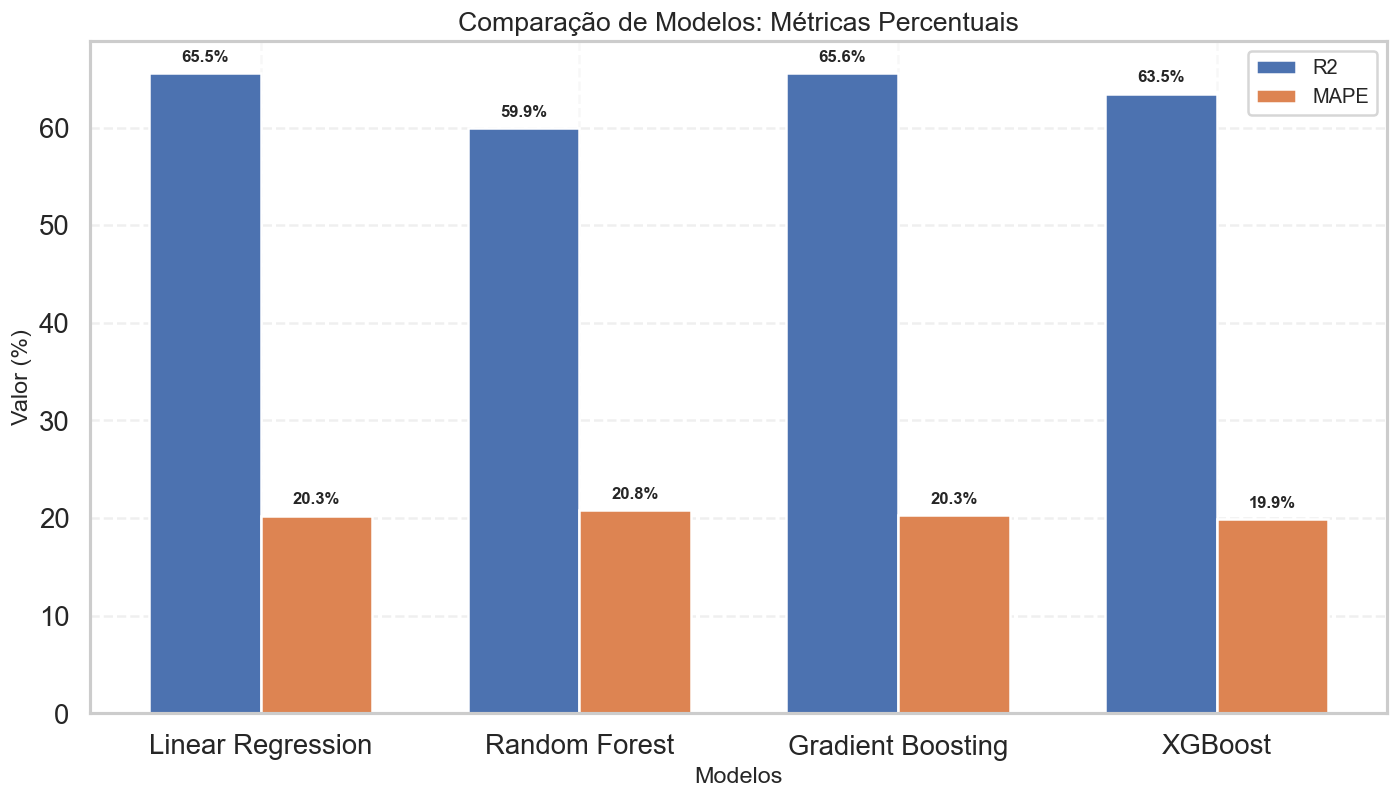

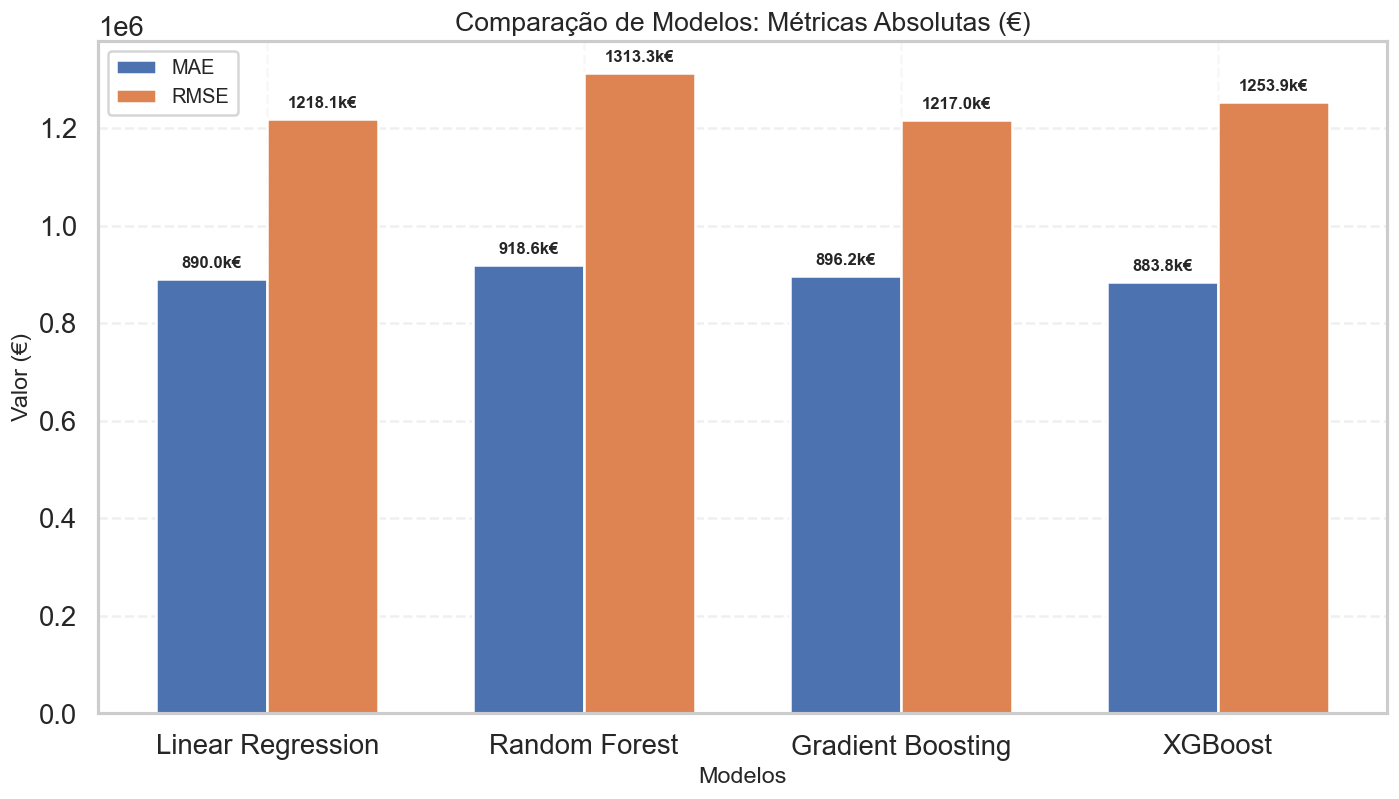

In [29]:
# Definimos os grupos de métricas para o loop
# O R2 e o MAPE são convertidos para %, o MAE e o RMSE ficam em Euros
groups = {
    "Métricas Percentuais": {"metrics": ["R2", "MAPE"], "suffix": "%", "multiplier": 100},
    "Métricas Absolutas (€)": {"metrics": ["MAE", "RMSE"], "suffix": "€", "multiplier": 1}
}

model_names = list(reg_results.keys())
x = np.arange(len(model_names))
bar_width = 0.35

for title, config in groups.items():
    plt.figure(figsize=(12, 7))
    
    for i, metric in enumerate(config["metrics"]):
        # Extraímos os valores e aplicamos o multiplicador (x100 para percentagens)
        values = [reg_results[model][metric] * config["multiplier"] for model in model_names]
        
        # Criamos as barras com um pequeno offset para não se sobreporem
        plt.bar(x + i * bar_width, values, width=bar_width, label=metric)
        
        # Adicionamos as anotações acima de cada barra
        for j, val in enumerate(values):
            # Se for Euro e o valor for grande, formatamos com 'k' para ser legível
            label_text = f"{val/1000:.1f}k€" if config["suffix"] == "€" and val > 1000 else f"{val:.1f}{config['suffix']}"
            
            plt.annotate(label_text,
                         xy=(x[j] + i * bar_width, val),
                         xytext=(0, 5),
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title(f"Comparação de Modelos: {title}", fontsize=16)
    plt.ylabel(f"Valor ({config['suffix']})", fontsize=14)
    plt.xlabel("Modelos", fontsize=14)
    plt.xticks(x + bar_width / 2, model_names)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

O **MAE (Erro Médio Absoluto)** representa o erro médio "puro" em unidades monetárias. Ao calcular a média das diferenças absolutas entre o valor real ($y_i$) e o previsto ($\hat{y}_i$), esta métrica indica-te diretamente quantos Euros (€), em média, o teu modelo falha por cada imóvel. É a métrica mais intuitiva para comunicar com stakeholders não técnicos, pois não distorce a escala do erro.
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

O **MSE (Erro Quadrático Médio)** é a função de custo que a maioria dos algoritmos, como o XGBoost, utiliza durante o treino. Ao elevar os erros ao quadrado, esta métrica amplifica drasticamente o impacto de erros grandes (outliers). Se o modelo falhar por 50.000€, o MSE contabiliza "2,5 mil milhões", o que força o algoritmo a minimizar desvios extremos para evitar penalizações pesadas no cálculo final.
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

O **RMSE (Raiz do Erro Quadrático Médio)** é a raiz quadrada do MSE, o que permite converter a penalização quadrática de volta para a escala de Euros (€). É a métrica de "consistência": se o RMSE for muito superior ao MAE, significa que o teu modelo está a cometer alguns erros de grande magnitude (possivelmente em mansões ou casas com preços atípicos) que estão a prejudicar a fiabilidade do sistema.
$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

O **MAPE (Erro Percentual Médio Absoluto)** é fundamental em imobiliário porque normaliza o erro pela escala do preço do imóvel. Um erro de 20.000€ numa casa de 100.000€ (20% de erro) é muito mais crítico do que numa de 1.000.000€ (2% de erro). O MAPE permite-te afirmar, com rigor, qual é a precisão relativa do modelo independentemente de estares a avaliar o segmento de luxo ou o económico.
$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

O **R² (Coeficiente de Determinação)** mede a eficácia do modelo em comparação com um modelo de referência que previsse sempre a média dos preços ($\bar{y}$). Um $R^2$ de 0.85 indica que o teu modelo consegue explicar 85% da variabilidade dos preços das casas. É a métrica de "ajuste" por excelência: quanto mais próximo de 1.0, melhor o modelo captou os padrões e tendências dos dados.
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$